
# Análisis Espacial de Proyectos de Fotogrametría con Drones

## Introducción

La fotogrametría mediante vehículos aéreos no tripulados (UAV) se ha consolidado como una tecnología fundamental para la generación de información geoespacial de alta resolución. Su aplicación permite producir ortomosaicos, modelos digitales de elevación y modelos tridimensionales utilizados en planificación territorial, monitoreo ambiental, agricultura de precisión e infraestructura (Colomina & Molina, 2014).

Asimismo, el uso de herramientas de ciencia de datos basadas en Python facilita la integración entre análisis estadístico, visualización de datos y cartografía interactiva (McKinney, 2022; Westra, 2022).

Para ello se utiliza un conjunto de datos conformado por proyectos de fotogrametría desarrollados en distintos tipos de terreno, considerando variables relacionadas con altura de vuelo, cantidad de imágenes capturadas, resolución espacial obtenida, tiempo de procesamiento y software empleado. El presente trabajo desarrolla un análisis exploratorio de proyectos de fotogrametría con drones utilizando bibliotecas especializadas de Python como Pandas, Matplotlib y Folium. 

El conjunto de datos contiene información de diez proyectos de fotogrametría realizados en diferentes entornos territoriales.

El análisis busca identificar patrones operativos asociados a la ejecución de proyectos fotogramétricos y explorar la relación entre las características de captura y los tiempos de procesamiento requeridos para la generación de productos cartográficos.

## Objetivos

### Objetivo General

Analizar datos de proyectos de fotogrametría con drones mediante técnicas estadísticas y herramientas de visualización espacial implementadas en Python.

### Objetivos Específicos

- Explorar estadísticamente las variables principales del conjunto de datos.
- Identificar relaciones entre la captura de imágenes y los tiempos de procesamiento.
- Visualizar patrones espaciales mediante mapas interactivos.
- Evaluar el comportamiento de los diferentes softwares fotogramétricos utilizados.


## Descripción del conjunto de datos


El conjunto de datos contiene información de diez proyectos fotogramétricos e incluye las siguientes variables:

-Proyecto: nombre del proyecto fotogramétrico.
-Tipo_Terreno: categoría temática del área de estudio.
-Altura_Vuelo_m: altura de vuelo utilizada durante la captura de imágenes.
-Imagenes: cantidad de fotografías obtenidas.
-Resolucion_cm_px: resolución espacial alcanzada.
-Tiempo_Procesamiento_min: tiempo total requerido para el procesamiento.
-Software: plataforma utilizada para el procesamiento fotogramétrico.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster, HeatMap

df = pd.read_csv('datos.csv')

df.head()


,Proyecto,Tipo_Terreno,Altura_Vuelo_m,Imagenes,Resolucion_cm_px,Tiempo_Procesamiento_min,Software
0,Zona Forestal,Bosque,120,450,3.2,95,Metashape
1,Area Agricola,Agricultura,100,380,2.8,80,Pix4D
2,Zona Urbana,Urbano,80,520,1.9,120,OpenDroneMap
3,Rio y Quebrada,Hidrologia,110,410,2.5,90,Metashape
4,Finca Cafetalera,Agricultura,90,360,2.2,75,Drone2Map


## Exploración inicial de los datos

In [2]:

df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Proyecto                  10 non-null     str    
 1   Tipo_Terreno              10 non-null     str    
 2   Altura_Vuelo_m            10 non-null     int64  
 3   Imagenes                  10 non-null     int64  
 4   Resolucion_cm_px          10 non-null     float64
 5   Tiempo_Procesamiento_min  10 non-null     int64  
 6   Software                  10 non-null     str    
dtypes: float64(1), int64(3), str(3)
memory usage: 692.0 bytes


,Altura_Vuelo_m,Imagenes,Resolucion_cm_px,Tiempo_Procesamiento_min
count,10.000000,10.00000,10.000000,10.000000
mean,102.500000,463.00000,2.640000,104.800000
std,22.515427,115.18584,0.794705,30.665942
min,70.000000,340.00000,1.500000,70.000000
25%,86.250000,382.50000,2.050000,82.000000
50%,100.000000,430.00000,2.600000,92.500000
75%,117.500000,510.00000,3.100000,127.500000
max,140.000000,700.00000,4.100000,160.000000



### Interpretación

Las estadísticas descriptivas permiten comprender el comportamiento general de las variables numéricas presentes en los proyectos analizados.


## Tabla de análisis con Pandas

In [3]:

tabla_software = df.groupby('Software').agg({
    'Tiempo_Procesamiento_min':'mean',
    'Imagenes':'mean',
    'Resolucion_cm_px':'mean'
}).round(2)

tabla_software


,Tiempo_Procesamiento_min,Imagenes,Resolucion_cm_px
Software,,,
Drone2Map,81.50,375.0,2.45
Metashape,115.00,520.0,2.40
OpenDroneMap,125.00,500.0,3.00
Pix4D,96.67,440.0,2.77



### Interpretación

La agrupación evidencia diferencias entre softwares respecto al tiempo promedio de procesamiento y las características de los proyectos ejecutados.


## Gráfico 1. Relación entre imágenes y tiempo de procesamiento

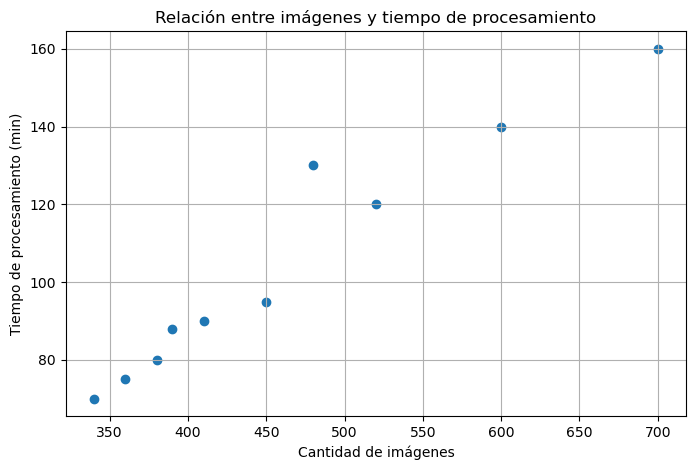

In [4]:

plt.figure(figsize=(8,5))
plt.scatter(df['Imagenes'], df['Tiempo_Procesamiento_min'])

plt.title('Relación entre imágenes y tiempo de procesamiento')
plt.xlabel('Cantidad de imágenes')
plt.ylabel('Tiempo de procesamiento (min)')
plt.grid(True)

plt.show()



### Interpretación

Existe una relación positiva entre la cantidad de imágenes capturadas y el tiempo requerido para procesar la información, comportamiento esperado en flujos de trabajo fotogramétricos (Colomina & Molina, 2014).


## Gráfico 2. Tiempo promedio de procesamiento por software

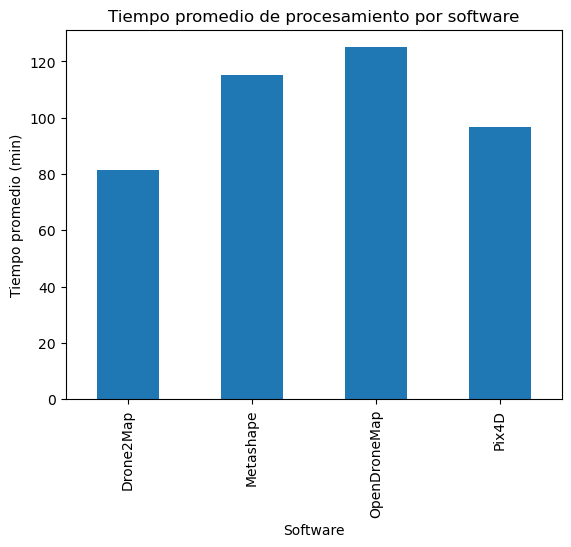

In [5]:

promedio = df.groupby('Software')['Tiempo_Procesamiento_min'].mean()

promedio.plot(kind='bar')

plt.title('Tiempo promedio de procesamiento por software')
plt.xlabel('Software')
plt.ylabel('Tiempo promedio (min)')

plt.show()



### Interpretación

Los resultados permiten comparar la eficiencia relativa de las plataformas utilizadas para el procesamiento fotogramétrico.


## Preparación de datos espaciales

In [12]:

coordenadas = [
[9.9333,-84.0833],
[10.0163,-84.2116],
[9.9907,-84.1293],
[10.0956,-84.4703],
[9.8644,-83.9194],
[10.6350,-85.4377],
[9.7489,-83.7534],
[10.3000,-84.4333],
[9.4439,-84.1437],
[10.3910,-84.4380]
]

df['Latitud'] = [x[0] for x in coordenadas]
df['Longitud'] = [x[1] for x in coordenadas]


## Mapa 1. Distribución espacial de proyectos

In [14]:

mapa1 = folium.Map(location=[9.9,-84.1], zoom_start=8)

cluster = MarkerCluster().add_to(mapa1)

for _, row in df.iterrows():
    popup=f'''
    Proyecto: {row["Proyecto"]}<br>
    Terreno: {row["Tipo_Terreno"]}<br>
    Software: {row["Software"]}
    '''
    folium.Marker(
        [row['Latitud'], row['Longitud']],
        popup=popup,
        tooltip=row['Proyecto']
    ).add_to(cluster)

mapa1



### Interpretación

Esta distribución espacial permite identificar la diversidad territorial de las aplicaciones fotogramétricas y facilita la exploración geográfica de los proyectos.


## Mapa 2. Mapa de calor de tiempos de procesamiento

In [9]:

mapa2 = folium.Map(location=[9.9,-84.1], zoom_start=8)

heat_data = [
[row['Latitud'], row['Longitud'], row['Tiempo_Procesamiento_min']]
for _, row in df.iterrows()
]

HeatMap(heat_data).add_to(mapa2)

mapa2



### Interpretación

El mapa de calor permite identificar zonas asociadas a mayores tiempos de procesamiento y facilita la detección visual de concentraciones espaciales.



## Discusión

Los resultados obtenidos muestran que existe una asociación entre el volumen de imágenes capturadas y el tiempo de procesamiento requerido. Asimismo, se observan diferencias entre los softwares empleados, lo que evidencia la influencia de las herramientas computacionales en la eficiencia de los proyectos.

Desde una perspectiva espacial, la distribución de los proyectos demuestra la versatilidad de la fotogrametría con drones para aplicaciones en ambientes urbanos, agrícolas, forestales e hidrológicos.

La integración de análisis estadístico y visualización espacial mediante Python representa una metodología eficiente para el estudio de datos geoespaciales.



## Conclusiones

1. Python constituye una plataforma robusta para el análisis de datos fotogramétricos. Pandas facilita la exploración y análisis estadístico de la información. Matplotlib permite representar relaciones entre variables de manera efectiva. Folium facilita la construcción de mapas interactivos para el análisis espacial.
2. Los proyectos con mayor cantidad de imágenes presentan mayores tiempos de procesamiento. Existen diferencias de rendimiento entre los distintos softwares utilizados.
3. Los mapas interactivos facilitan la interpretación espacial de los proyectos y complementan los análisis estadísticos tradicionales.



# Referencias Bibliográficas

Colomina, I., & Molina, P. (2014). Unmanned aerial systems for photogrammetry and remote sensing: A review. *ISPRS Journal of Photogrammetry and Remote Sensing, 92*, 79–97. https://doi.org/10.1016/j.isprsjprs.2014.02.013

Goodchild, M. F. (2007). Citizens as sensors: The world of volunteered geography. *GeoJournal, 69*(4), 211–221.https://doi.org/10.1007/s10708-007-9111-y

Lillesand, T. M., Kiefer, R. W., & Chipman, J. W. (2015). *Remote sensing and image interpretation* (7th ed.). Wiley.

Oliphant, T. E. (2006). A guide to NumPy. Trelgol Publishing.

McKinney, W. (2022). *Python for data analysis* (3rd ed.). O'Reilly Media.

OpenStreetMap Contributors. (2025). OpenStreetMap. https://www.openstreetmap.org

Reitz, P., & Biocca, M. (2023). Folium Documentation. https://python-visualization.github.io/folium/

Van Rossum, G., & Drake, F. (2009). *Python 3 Reference Manual*. CreateSpace.

Westra, E. (2022). *Python Geospatial Development* (4th ed.). Packt Publishing.
Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Westra, E. (2022). Python geospatial development (4th ed.). Packt Publishing.

Zar, J. H. (2010). Biostatistical analysis (5th ed.). Pearson Education.